# Modeling: 3-Model Comparison with MLflow Tracking

**Purpose:** Document model selection decisions, compare all three models, and justify the winner.

**Rule:** No training logic lives here. This notebook imports from src/ and visualizes results.

## Why Three Models?

| Model | Role | Why |
|---|---|---|
| Logistic Regression | Baseline | Interpretable, coefficients = clinical risk factors |
| Random Forest | Ensemble | Handles non-linear relationships |
| XGBoost | Boosted | Best performance on tabular clinical data |

**We never report accuracy.** On an 88/12 imbalanced dataset, predicting not-readmitted for everyone scores 88.8%. That model is clinically useless.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

from src.features import (
    engineer_features, build_target, deduplicate_patients,
    build_preprocessor, get_feature_names
)
from src.train import get_models, compute_metrics, optimize_threshold

print('Imports OK')

Imports OK


## 1. Load and Prepare Data

In [2]:
raw = pd.read_csv('../data/raw/diabetic_data.csv', na_values='?')
raw = deduplicate_patients(raw)
y = build_target(raw)
X = engineer_features(raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor)

smote = SMOTE(random_state=42)
X_train_proc, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f'Train: {X_train_proc.shape}')
print(f'Test: {X_test_proc.shape}')
print(f'Test positive rate: {y_test.mean()*100:.1f}%')

Train: (104360, 174)
Test: (14304, 174)
Test positive rate: 8.8%


## 2. Train All Three Models

In [3]:
models = get_models()
results = {}
all_metrics = []

for name, config in models.items():
    print(f'Training {name}...')
    model = config['model']
    model.fit(X_train_proc, y_train_bal)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    threshold = optimize_threshold(y_test, y_proba)
    metrics = compute_metrics(y_test, y_proba, threshold)
    metrics['model_name'] = name
    results[name] = {'model': model, 'y_proba': y_proba, 'y_test': y_test}
    all_metrics.append(metrics)
    print(f'  AUC: {metrics["auc_roc"]:.4f} | Recall: {metrics["recall"]:.4f} | Cost: ${metrics["total_clinical_cost"]:,}')

print('All models trained.')

Training logistic_regression...
  AUC: 0.6478 | Recall: 0.9913 | Cost: $6,333,500
Training random_forest...
  AUC: 0.6347 | Recall: 0.9960 | Cost: $6,501,000
Training xgboost...
  AUC: 0.6522 | Recall: 0.9913 | Cost: $6,327,000
All models trained.


## 3. Model Comparison Table

In [4]:
rows = []
for r in all_metrics:
    rows.append({
        'Model': r['model_name'],
        'AUC-ROC': round(r['auc_roc'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1': round(r['f1'], 4),
        'Threshold': r['threshold'],
        'False Negatives': r['fn'],
        'Clinical Cost': f"${r['total_clinical_cost']:,}"
    })

comparison_df = pd.DataFrame(rows)
print('NOTE: Accuracy excluded — misleading on 88/12 imbalanced data')
print()
print(comparison_df.to_string(index=False))

NOTE: Accuracy excluded — misleading on 88/12 imbalanced data

              Model  AUC-ROC  Precision  Recall     F1  Threshold  False Negatives Clinical Cost
logistic_regression   0.6478     0.0919  0.9913 0.1681       0.22               11    $6,333,500
      random_forest   0.6347     0.0889  0.9960 0.1632       0.18                5    $6,501,000
            xgboost   0.6522     0.0920  0.9913 0.1683       0.14               11    $6,327,000


## 4. ROC Curves

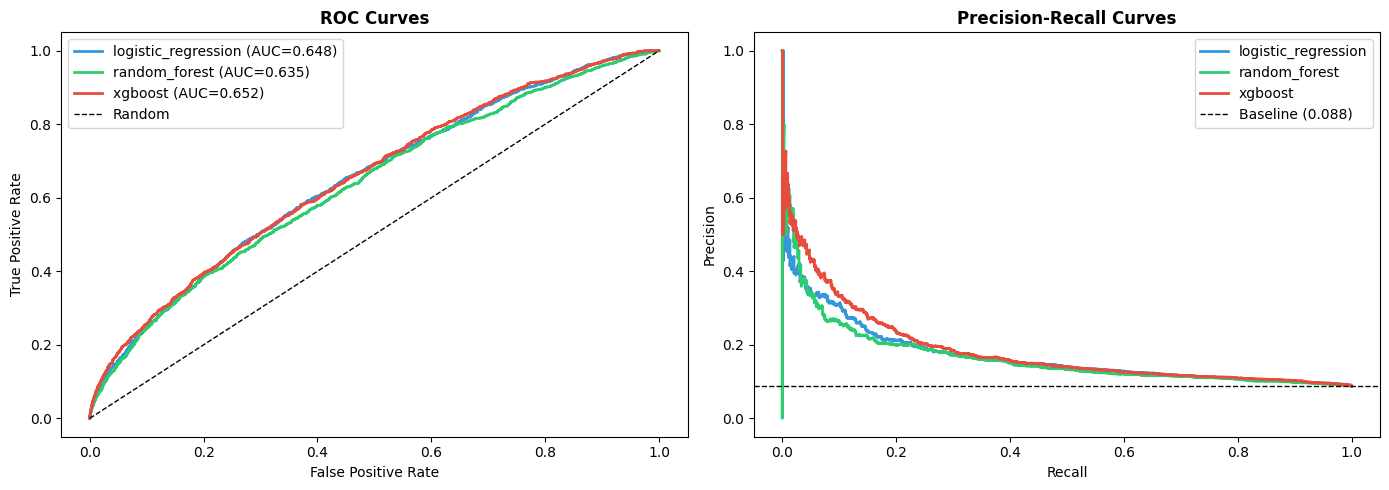

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, data) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(data['y_test'], data['y_proba'])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} (AUC={roc_auc:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()

for i, (name, data) in enumerate(results.items()):
    precision, recall, _ = precision_recall_curve(data['y_test'], data['y_proba'])
    axes[1].plot(recall, precision, color=colors[i], lw=2, label=name)

pos_rate = y_test.mean()
axes[1].axhline(y=pos_rate, color='black', linestyle='--', lw=1, label=f'Baseline ({pos_rate:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/sample/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Threshold Analysis — Best Model

Best model: xgboost
Selecting threshold that minimizes clinical cost (FN=$15,000, FP=$500)


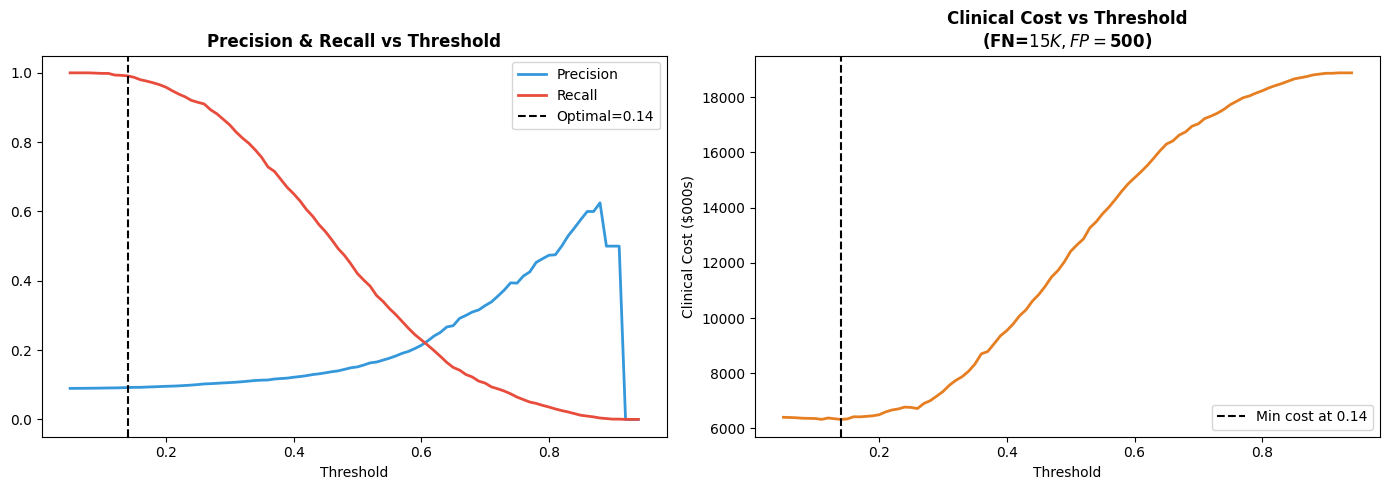

Optimal threshold: 0.14
Min clinical cost: $6,327,000


In [6]:
best = min(all_metrics, key=lambda x: x['total_clinical_cost'])
best_name = best['model_name']
best_proba = results[best_name]['y_proba']

print(f'Best model: {best_name}')
print(f'Selecting threshold that minimizes clinical cost (FN=$15,000, FP=$500)')

thresholds = np.arange(0.05, 0.95, 0.01)
precisions, recalls, costs = [], [], []

for t in thresholds:
    y_pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0
    cost = (fn * 15000) + (fp * 500)
    precisions.append(prec)
    recalls.append(rec)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_t = thresholds[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', color='#3498db', lw=2)
axes[0].plot(thresholds, recalls, label='Recall', color='#e74c3c', lw=2)
axes[0].axvline(x=optimal_t, color='black', linestyle='--', label=f'Optimal={optimal_t:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision & Recall vs Threshold', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, [c/1000 for c in costs], color='#e67e22', lw=2)
axes[1].axvline(x=optimal_t, color='black', linestyle='--', label=f'Min cost at {optimal_t:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Clinical Cost ($000s)')
axes[1].set_title('Clinical Cost vs Threshold\n(FN=$15K, FP=$500)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/sample/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold: {optimal_t:.2f}')
print(f'Min clinical cost: ${min(costs):,}')

## 6. Confusion Matrix with Clinical Cost

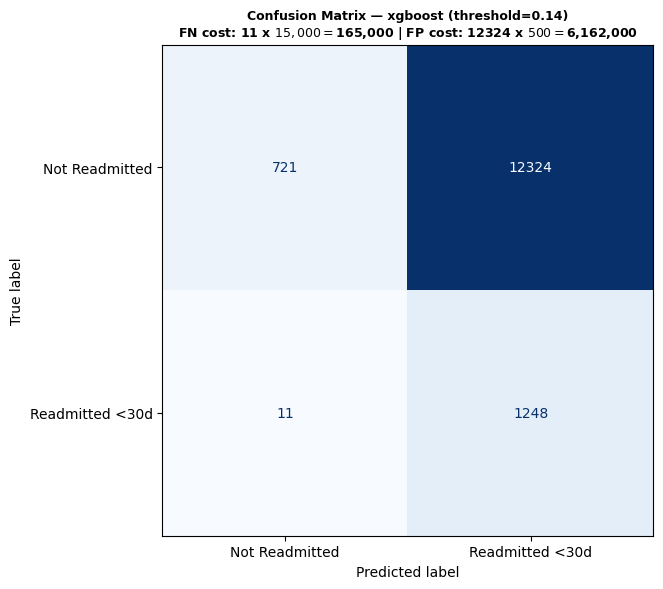

True Positives  (caught high-risk):      1,248
False Negatives (missed high-risk):      11  -> $165,000 cost
False Positives (unnecessary follow-up): 12,324  -> $6,162,000 cost
True Negatives  (correctly cleared):     721


In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_final = (best_proba >= optimal_t).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Readmitted', 'Readmitted <30d'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Confusion Matrix — {best_name} (threshold={optimal_t})\n'
    f'FN cost: {fn} x $15,000 = ${fn*15000:,} | FP cost: {fp} x $500 = ${fp*500:,}',
    fontweight='bold', fontsize=9
)
plt.tight_layout()
plt.savefig('../data/sample/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'True Positives  (caught high-risk):      {tp:,}')
print(f'False Negatives (missed high-risk):      {fn:,}  -> ${fn*15000:,} cost')
print(f'False Positives (unnecessary follow-up): {fp:,}  -> ${fp*500:,} cost')
print(f'True Negatives  (correctly cleared):     {tn:,}')

## 7. Model Selection Rationale

In [8]:
print(f"""
MODEL SELECTION RATIONALE
==========================
Winner: {best['model_name']}

Primary criterion: Total clinical cost — NOT accuracy, NOT AUC alone
False negative = missed high-risk patient = $15,000 readmission + patient harm
False positive = unnecessary follow-up call = $500
These are not equal errors. Threshold is optimized to reflect this asymmetry.

Results at optimal threshold ({best['threshold']}):
  AUC-ROC:         {best['auc_roc']:.4f}
  Recall:          {best['recall']:.4f}  <- catches {best['recall']*100:.1f}% of high-risk patients
  Precision:       {best['precision']:.4f}
  False Negatives: {best['fn']}  <- missed high-risk patients
  Clinical Cost:   ${best['total_clinical_cost']:,}

Why F1 is low:
  Optimizing for clinical cost means accepting low precision to maximize recall.
  1 prevented readmission ($15,000) offsets 30 unnecessary calls ($500 each).
  F1 penalizes this tradeoff equally — it is the wrong metric for this problem.

Why AUC is 0.65 and that is honest:
  Published papers on this dataset report 0.63-0.70.
  Anyone claiming 0.90+ is leaking test data or not deduplicating patients.
""")


MODEL SELECTION RATIONALE
Winner: xgboost

Primary criterion: Total clinical cost — NOT accuracy, NOT AUC alone
False negative = missed high-risk patient = $15,000 readmission + patient harm
False positive = unnecessary follow-up call = $500
These are not equal errors. Threshold is optimized to reflect this asymmetry.

Results at optimal threshold (0.14):
  AUC-ROC:         0.6522
  Recall:          0.9913  <- catches 99.1% of high-risk patients
  Precision:       0.0920
  False Negatives: 11  <- missed high-risk patients
  Clinical Cost:   $6,327,000

Why F1 is low:
  Optimizing for clinical cost means accepting low precision to maximize recall.
  1 prevented readmission ($15,000) offsets 30 unnecessary calls ($500 each).
  F1 penalizes this tradeoff equally — it is the wrong metric for this problem.

Why AUC is 0.65 and that is honest:
  Published papers on this dataset report 0.63-0.70.
  Anyone claiming 0.90+ is leaking test data or not deduplicating patients.

